## Table of Contents
1. [Introduction](#introduction)
2. [Setup and Imports](#setup)
3. [Loading the Fashion MNIST Dataset](#load)
4. [Data Exploration & Visualization](#explore)
5. [Data Preprocessing](#preprocess)
6. [Model Building (DNN)](#dnn)
7. [Training the Model](#train)
8. [Performance Visualization](#visual)
9. [Predictions & Confusion Matrix](#predict)
10. [Making Predictions on New Images](#inference)
11. [Saving the Trained Model](#save-model)
12. [Loading a Pretrained Model](#load-model)

## 1. Introduction

In this section, we will introduce the **Fashion MNIST dataset** and the goal of this notebook, which is to build and train a **Deep Learning model** using TensorFlow/Keras to classify fashion items.

---

### 1.1 What is the Fashion MNIST Dataset?

The **Fashion MNIST** dataset is a collection of **60,000 training** and **10,000 test** images of fashion items, such as clothing and accessories. Each image is **28x28 pixels** in grayscale, and the dataset consists of **10 classes**, including items like T-shirts, dresses, and sneakers.

---

### 1.2 Dataset Structure

The dataset consists of the following:
- **Training set**: 60,000 grayscale images (28x28 pixels)
- **Test set**: 10,000 images used for evaluating the trained model.

Each image belongs to one of the following 10 classes:
1. T-shirt/top
2. Trouser
3. Pullover
4. Dress
5. Coat
6. Sandal
7. Shirt
8. Sneaker
9. Bag
10. Ankle boot

---

### 1.3 Goal of this Notebook

The objective of this notebook is to:
1. **Preprocess** the Fashion MNIST dataset by normalizing and reshaping the images.
2. **Build and train** a deep learning model (fully connected neural network).
3. **Evaluate** the model's performance on the test set.
4. **Make predictions** on new, unseen images.
5. **Save and load** the trained model for future use.

## 2. Setup and Imports

In [7]:
# Core libraries for data manipulation and visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Evaluation and splitting tools
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully ")

TensorFlow version: 2.20.0
All libraries imported successfully 


---

# 3. Loading the Fashion MNIST Dataset

In [6]:
# Load Fashion MNIST directly from Keras
fashion_mnist = keras.datasets.fashion_mnist
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

# Define the class names for all 10 categories
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Dataset loaded successfully ")
print(f"Training set shape : {x_train_full.shape}")
print(f"Test set shape     : {x_test.shape}")
print(f"Number of classes  : {len(class_names)}")

Dataset loaded successfully 
Training set shape : (60000, 28, 28)
Test set shape     : (10000, 28, 28)
Number of classes  : 10


In [ ]:
!git add .
!git commit -m "Lenah - Sections 1, 2, 3 done"
!git push

[main 5d54cb6] Lenah - Sections 1, 2, 3 done
 1 file changed, 231 insertions(+), 4 deletions(-)


To https://github.com/lenahmahmoud/Neural_Task.git
   625803c..5d54cb6  main -> main


In [8]:
#check
class_names[1]

'Trouser'

# 4. Data Exploration & Visualization

### 4.1 Dataset Shape and Basic Information

In [9]:
print("Training data shape :", x_train_full.shape)
print("Test data shape     :", x_test.shape)
print("Training labels     :", y_train_full.shape)
print("Test labels         :", y_test.shape)

unique_classes = np.unique(y_train_full)
print("\nNumber of classes:", len(unique_classes))
print("Class labels      :", unique_classes)
print('----------------------------------------')
print('X Train sample  is :', x_train_full[5])
print('----------------------------------------')
print('X Test  sample  is :', x_test[5])
print('----------------------------------------')

Training data shape : (60000, 28, 28)
Test data shape     : (10000, 28, 28)
Training labels     : (60000,)
Test labels         : (10000,)

Number of classes: 10
Class labels      : [0 1 2 3 4 5 6 7 8 9]
----------------------------------------
X Train sample  is : [[  0   0   0   0   1   0   0   0   0  22  88 188 172 132 125 141 199 143
    9   0   0   0   1   0   0   0   0   0]
 [  0   0   0   1   0   0  20 131 199 206 196 202 242 255 255 250 222 197
  206 188 126  17   0   0   0   0   0   0]
 [  0   0   0   1   0  35 214 191 183 178 175 168 150 162 159 152 158 179
  183 189 195 185  82   0   0   0   0   0]
 [  0   0   0   0   0 170 190 172 177 176 171 169 162 155 148 154 169 174
  175 175 177 183 188  12   0   0   0   0]
 [  0   0   0   0  25 194 180 178 174 184 187 189 187 184 181 189 200 197
  193 190 178 175 194  90   0   0   0   0]
 [  0   0   0   0  42 218 191 197 208 204 211 209 210 212 211 214 215 213
  214 211 211 191 200 158   0   0   0   0]
 [  0   0   0   0  88 221 215 217

### 4.2 Sample Images

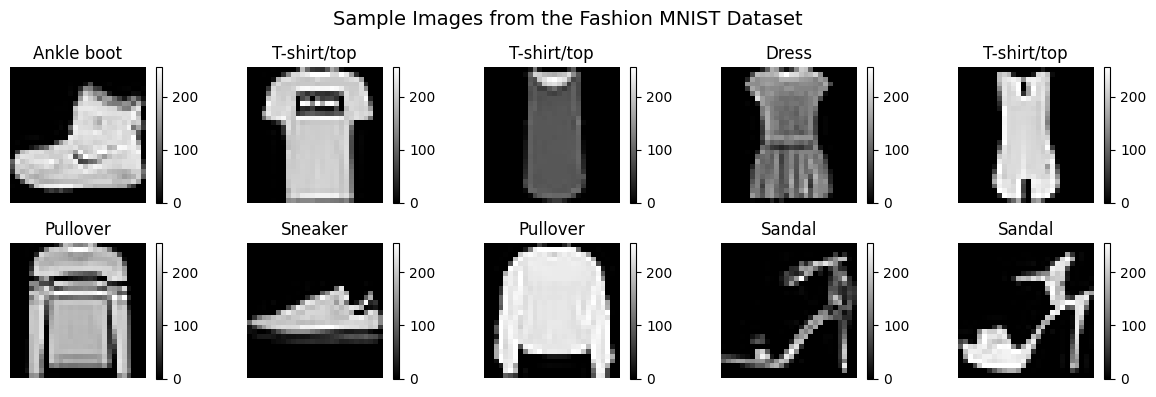

In [10]:
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_full[i], cmap='gray')
    plt.colorbar()
    plt.title(class_names[y_train_full[i]])
    plt.axis('off')
plt.suptitle("Sample Images from the Fashion MNIST Dataset", fontsize=14)
plt.tight_layout()
plt.show()

### 4.3 Class Distribution

#### — Bar Chart

/tmp/ipykernel_17039/2079908105.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_full, palette="Set2")


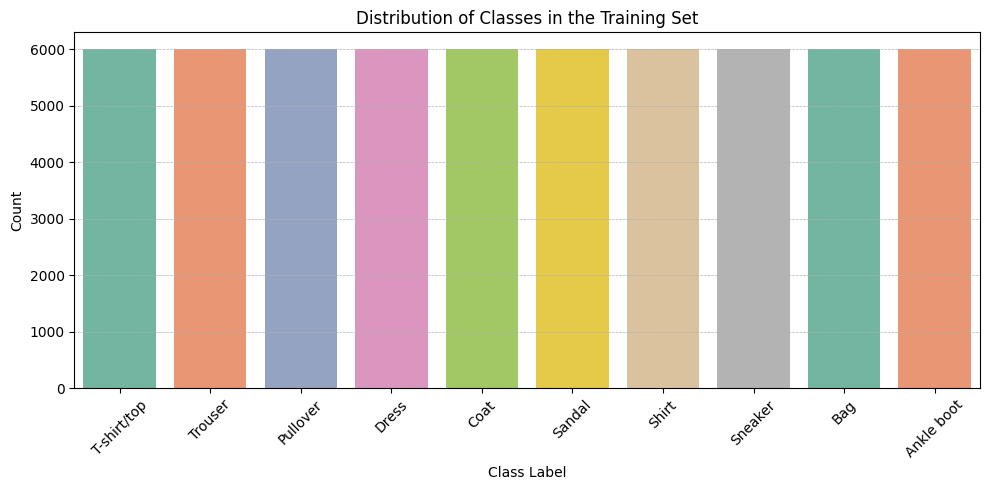

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train_full, palette="Set2")
plt.title("Distribution of Classes in the Training Set")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.xticks(ticks=np.arange(10), labels=class_names, rotation=45)
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

#### — Pie Chart

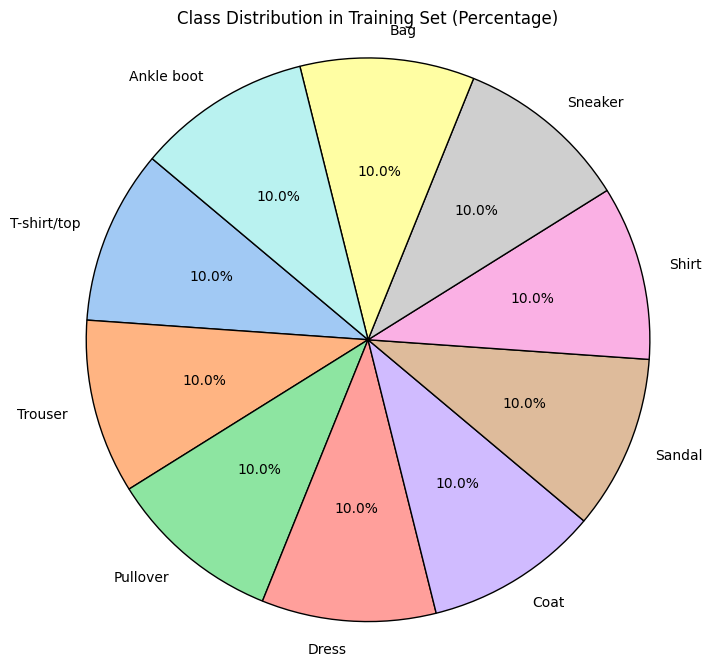

In [14]:

class_counts = np.bincount(y_train_full)


plt.figure(figsize=(8, 8))
plt.pie(class_counts,
        labels=class_names,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'),
        wedgeprops={'edgecolor': 'black'})
plt.title("Class Distribution in Training Set (Percentage)", loc='center')
plt.axis('equal')
plt.show()